# 202235203 고수호
# **3week - wine 딕셔너리 데이터에 대한 Regression**

# **# 데이터 세트 불러오기**
`from sklearn import datasets` : **사이킷런**에서 제공하는 여러 가지 연습용 데이터 세트 묶음.   
`import pandas as pd` : 데이터를 표(Table) 형태로 다루기 위한 **Pandas** 라이브러리.  
`import numpy as np` : 수치 계산 및 행렬 연산을 위한 **NumPy** 라이브러리.  
`import matplotlib.pyplot as plt` : 데이터를 그래프로 시각화하기 위한 **Matplotlib** 라이브러리.  
`data = datasets.load_wine()` : 그중 **와인 분류**를 위한 데이터(178개 샘플, 13개 특징)를 로드하여 **data** 변수에 저장.


In [1]:
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = datasets.load_wine()

# **# 데이터셋 분리 (Training & Test Set)**
`x = data.data` : 와인의 화학적 성분 데이터(특징)를 변수 **x**에 저장.  
`y = data.target` : 와인의 종류(정답)를 변수 **y**에 저장.  
`test_size = 0.2` : 전체 데이터의 **20%** 를 평가용(Test)으로, **80%** 를 학습용(Train)으로 설정.   
`random_state=4` : 실행할 때마다 동일한 결과가 나오도록 난수 시드 고정.  
`X_train.shape` : 학습용 특징 데이터의 크기 확인 (행의 개수, 열의 개수).  
`X_test.shape` : 테스트용 특징 데이터의 크기 확인 (행의 개수, 열의 개수).

In [2]:
from  sklearn.model_selection import train_test_split
x = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=4)

print(X_train.shape)
print(X_test.shape)

(142, 13)
(36, 13)


# **# 모델별 학습 및 평가**
**1 - 선형 회귀 (Linear Regression) : lr**  
**2 - 결정 트리 (Decision Tree) : dt**  
**3 - 랜덤 포레스트 (Random Forest) : rf**  
**4 - kNN 알고리즘 (k-Nearest Neighbor) : knn**

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

model_lr = LinearRegression()
model_dt = DecisionTreeRegressor()
model_rf = RandomForestRegressor()
knn = KNeighborsRegressor(n_neighbors=6)

model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

ly_preds = model_lr.predict(X_test)
dy_preds = model_dt.predict(X_test)
ry_preds = model_rf.predict(X_test)
y_pred = knn.predict(X_test)

print ("\n--- Linear Regression ---")
print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

print ("\n--- Decision Tree ---")
print('평균제곱근오차', mean_squared_error(dy_preds, y_test))

print ("\n--- Random Forest ---")
print('평균제곱근오차', mean_squared_error(ry_preds, y_test))

print ("\n--- kNN ---")
print('평균제곱근오차', mean_squared_error(y_pred, y_test))


--- Linear Regression ---
평균제곱근오차 0.06696862960242086
평균제곱근오차 0.06696862960242086
평균제곱근오차 0.06696862960242086

--- Decision Tree ---
평균제곱근오차 0.027777777777777776

--- Random Forest ---
평균제곱근오차 0.017091666666666668

--- kNN ---
평균제곱근오차 0.32947530864197533


# **# 시각화를 통한 모델 성능 확인**
**1 - 선형 회귀 (Linear Regression) : lr**  
**2 - 결정 트리 (Decision Tree) : dt**  
**3 - 랜덤 포레스트 (Random Forest) : rf**  
**4 - kNN 알고리즘 (k-Nearest Neighbor) : knn**  
`plt.scatter(X_test[:, 5], y_test, label='y_test')` :
- **X_test[:, 5]** : 테스트 데이터의 6번째 열(예: 페놀 함량) 데이터를 $x$축으로 설정.
- **y_test** : 실제 와인 종류(정답)를 $y$축으로 설정하여 점을 찍음.
- **label='y_test'** : 이 점들의 이름을 'y_test'로 정의(범례용).



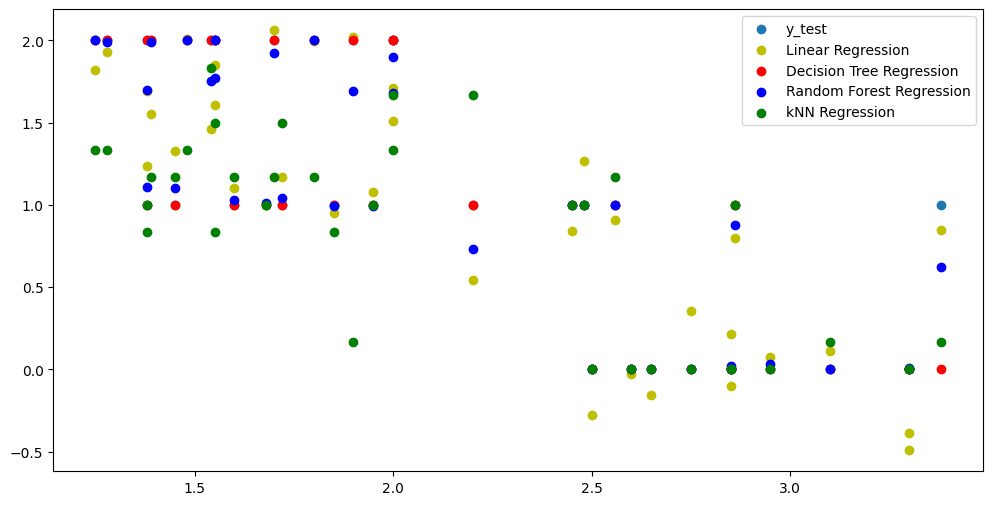

In [13]:
plt.figure(figsize=(12, 6))

plt.scatter(X_test[:, 5], y_test, label='y_test')

plt.scatter(X_test[:, 5], ly_preds, c='y', label='Linear Regression')
plt.scatter(X_test[:, 5], dy_preds, c='r', label='Decision Tree Regression')
plt.scatter(X_test[:, 5], ry_preds, c='b', label='Random Forest Regression')
plt.scatter(X_test[:, 5], y_pred, c='green', label='kNN Regression')

plt.legend()
plt.show()